In [1]:
import sys
from pathlib import Path
import os
sys.path.append(str(Path.cwd().parent))
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch

from src.model import UNet


device = torch.device("mps")

model = UNet().to(device)

model.load_state_dict(
    torch.load(
        "../models/epoch20_best_model.pt",
        map_location=device,
    )
)

model.eval()

""

''

In [3]:
def predict(model, image, device, threshold=0.5):
    model.eval()

    with torch.no_grad():
        image = image.unsqueeze(0).to(device)

        logits = model(image)

        probability = torch.sigmoid(logits)

        prediction = probability >= threshold

    return (
        probability.squeeze().cpu().numpy(),
        prediction.squeeze().cpu().numpy(),
    )

from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
from src.dataset import OilSpillDataset

val_dataset = OilSpillDataset(
    image_dir="../data/images/val",
    mask_dir="../data/masks/val",
)

print("val:", len(val_dataset))

val: 1615


In [5]:
from src.polygon import mask_to_polygons

image, ground_truth = val_dataset[0]

probability, prediction = predict(
    model,
    image,
    device,
)

polygons = mask_to_polygons(
    prediction,
    min_area=20,
)

print("number of polygons:", len(polygons))

for i, polygon in enumerate(polygons):
    print(
        f"polygon {i}: "
        f"{len(polygon)} vertices"
    )

number of polygons: 7
polygon 0: 78 vertices
polygon 1: 15 vertices
polygon 2: 42 vertices
polygon 3: 84 vertices
polygon 4: 37 vertices
polygon 5: 12 vertices
polygon 6: 100 vertices


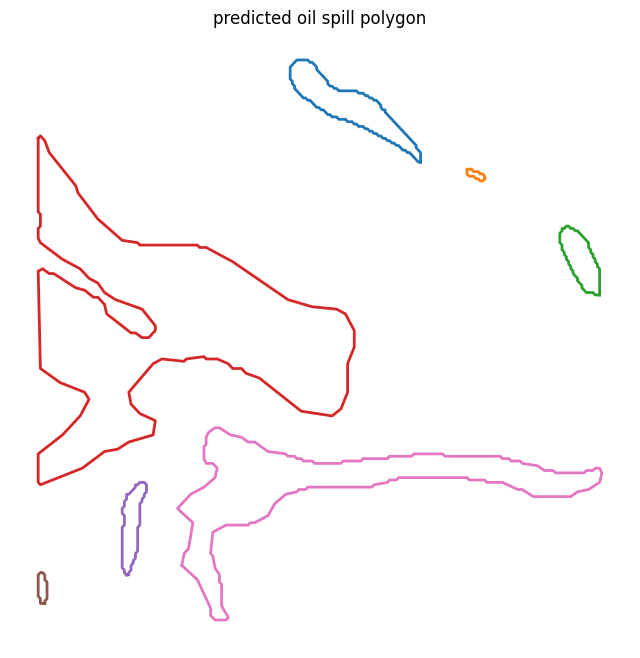

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 8))

#plt.imshow(
#    image.squeeze(),
#    cmap="gray",
#)

for polygon in polygons:

    closed = np.vstack([
        polygon,
        polygon[0],
    ])

    plt.plot(
        closed[:, 0],
        closed[:, 1],
        linewidth=2,
    )

plt.axis("off")
plt.title("predicted oil spill polygon")

plt.show()